# FedPrivTab：交互形式 + API 形式对比三个模型

GitHub：https://github.com/oneflow1/FedPrivTab

生成时间：2026-06-18 06:13:49 UTC。本 Notebook 对照展示 FedPrivTab 的交互式产品流程与真实 API 训练脚本，研究对象包括 Adult 收入二分类、集中式 MLP、FedAvg MLP、DP-FedAvg MLP、噪声与 alpha 敏感性。

## 一、交互形式：产品精简版训练流程

这一部分按 README 风格概览 FedPrivTab 的产品化训练路径：先登录进入工作台，再完成客户端数据准备，随后分别运行集中式 MLP、FedAvg MLP 和 DP-FedAvg MLP，最后在结果分析页查看指标与曲线。

![登录页：输入账号后进入 FedPrivTab 产品工作台。](ui_screenshots/01_login.png)

图：登录页：输入账号后进入 FedPrivTab 产品工作台。

![首页工作台：从导航入口进入数据准备、模型训练和结果分析流程。](ui_screenshots/02_home.png)

图：首页工作台：从导航入口进入数据准备、模型训练和结果分析流程。

![客户端数据准备：上传或选择各客户端 CSV，完成联邦训练前的数据校验与预处理。](ui_screenshots/03_client_data_preparation.png)

图：客户端数据准备：上传或选择各客户端 CSV，完成联邦训练前的数据校验与预处理。

![集中式 MLP 训练：选择合并数据集并配置 epochs、学习率和 MLP 结构。](ui_screenshots/04_centralized_training.png)

图：集中式 MLP 训练：选择合并数据集并配置 epochs、学习率和 MLP 结构。

![分布式 FedAvg / DP-FedAvg 训练：选择客户端数据集、通信轮次、客户端比例和 DP 参数。](ui_screenshots/05_distributed_training.png)

图：分布式 FedAvg / DP-FedAvg 训练：选择客户端数据集、通信轮次、客户端比例和 DP 参数。

![结果分析：对比集中式 MLP、FedAvg MLP 与 DP-FedAvg MLP 的训练曲线和指标。](ui_screenshots/06_results_analysis.png)

图：结果分析：对比集中式 MLP、FedAvg MLP 与 DP-FedAvg MLP 的训练曲线和指标。


## 二、API 形式：真实接口训练脚本

API 执行模式：`http`。集中式数据预处理行数：，特征维度：。

预处理调用 `/preprocess?async=true`，随后轮询 `/jobs/<id>`；训练调用 `/train`。`experiment_results.json` 是 `/train` API 响应对象的缓存副本；当 `RUN_API_EXPERIMENTS=False` 时从该缓存恢复 `api_results`，当 `RUN_API_EXPERIMENTS=True` 时同一个 `api_results` 变量直接来自实时 `/train` 调用。

## 默认配置来源

主实验默认配置由紧凑消融实验选择，消融记录保存于 `default_config_ablation.json`。集中式 MLP、FedAvg MLP 与 DP-FedAvg MLP 都使用相同 MLP 架构：`hidden_layers=2`、`hidden_units='64,32'`、`activation='ReLU'`。

In [1]:
import json
import time
from pathlib import Path

import requests

API_BASE = 'http://127.0.0.1:5000'
RUN_API_EXPERIMENTS = False
ROOT = Path('.')
OUT_DIR = ROOT / 'data/mywork/final_outputs'
RESULTS_JSON = OUT_DIR / 'experiment_results.json'


def post_preprocess(csv_path, client_id=None, role='centralized'):
    """Upload one CSV to /preprocess?async=true. role is 'client'/'centralized'."""
    csv_path = Path(csv_path)
    data = {'role': role}
    if client_id is not None:
        data['client_id'] = client_id
    with csv_path.open('rb') as fh:
        files = {'file': (csv_path.name, fh, 'text/csv')}
        response = requests.post(
            f'{API_BASE}/preprocess?async=true',
            files=files,
            data=data,
            timeout=60,
        )
    response.raise_for_status()
    return response.json()


def wait_job(job_id, poll_seconds=2, timeout_seconds=1800):
    """Poll /jobs/<job_id> until the async preprocessing job completes or fails."""
    deadline = time.time() + timeout_seconds
    while time.time() < deadline:
        response = requests.get(f'{API_BASE}/jobs/{job_id}', timeout=30)
        response.raise_for_status()
        payload = response.json()
        job = payload.get('job', payload)
        status = job.get('status')
        if status in {'completed', 'failed'}:
            if status == 'failed':
                raise RuntimeError(job)
            return job
        time.sleep(poll_seconds)
    raise TimeoutError(f'Job {job_id} did not finish within {timeout_seconds} seconds')


def completed_preprocess_result(start_response):
    job = start_response.get('job', start_response)
    job_id = job.get('job_id') or job.get('id')
    if job_id:
        job = wait_job(job_id)
        return job.get('result', job)
    return start_response


def post_train(payload):
    response = requests.post(f'{API_BASE}/train', json=payload, timeout=1800)
    response.raise_for_status()
    return response.json()


client_csvs = [
    ('client-1', ROOT / 'data/processed/adult_noniid_client_1.csv'),
    ('client-2', ROOT / 'data/processed/adult_noniid_client_2.csv'),
    ('client-3', ROOT / 'data/processed/adult_noniid_client_3.csv'),
    ('client-4', ROOT / 'data/processed/adult_noniid_client_4.csv'),
]

if RUN_API_EXPERIMENTS:
    central_preprocess = completed_preprocess_result(
        post_preprocess(ROOT / 'data/raw/adult.csv', role='centralized')
    )
    client_preprocess = [
        completed_preprocess_result(post_preprocess(csv_path, client_id=client_id, role='client'))
        for client_id, csv_path in client_csvs
    ]
else:
    # experiment_results.json is a cached copy of previous /train API responses.
    # It is used only when RUN_API_EXPERIMENTS=False to avoid rerunning heavy training.
    if not RESULTS_JSON.exists():
        raise FileNotFoundError(
            f'{RESULTS_JSON} is missing. Run scripts/generate_postproject_cache.py while the local Flask API is reachable.'
        )
    saved = json.loads(RESULTS_JSON.read_text(encoding='utf-8'))
    central_preprocess = saved['metadata']['central_preprocess']
    client_preprocess = saved['metadata']['client_preprocess']

central_dataset_id = central_preprocess['dataset_id']
client_dataset_ids = [
    item['dataset_id']
    for item in client_preprocess
]
client_datasets = [
    {'client_id': item['client_id'], 'dataset_id': item['dataset_id']}
    for item in client_preprocess
]

centralized_payload = {
    'target_column': 'income',
    'batch_size': 128,
    'hidden_layers': 2,
    'hidden_units': '64,32',
    'activation': 'ReLU',
    'epochs': 50,
    'lr': 0.05,
    'lr_schedule': 'step_decay',
    'lr_decay': 0.5,
    'lr_step_size': 15,
    'lr_min': 0.005,
    'seed': 42,
    'mode': 'centralized',
    'dataset_id': central_dataset_id,
}

fedavg_payload = {
    'target_column': 'income',
    'clients': 4,
    'local_epochs': 1,
    'batch_size': 32,
    'hidden_layers': 2,
    'hidden_units': '64,32',
    'activation': 'ReLU',
    'rounds': 50,
    'lr': 0.05,
    'lr_schedule': 'step_decay',
    'lr_decay': 0.5,
    'lr_step_size': 15,
    'lr_min': 0.005,
    'seed': 42,
    'client_fraction': 1.0,
    'mode': 'fedavg',
    'dirichlet_alpha': 0.3,
    'client_dataset_ids': client_dataset_ids,
    'client_datasets': client_datasets,
}

dp_fedavg_payload = {
    **fedavg_payload,
    'mode': 'dp_fedavg',
    'noise_multiplier': 0.1,
    'lr': 0.03,
    'lr_schedule': 'step_decay',
    'lr_decay': 0.5,
    'lr_step_size': 15,
    'lr_min': 0.005,
    'epsilon': 4.0,
    'delta': 1e-5,
    'clip_norm': 1.0,
}

if RUN_API_EXPERIMENTS:
    api_results = [
        {'name': 'centralized_mlp', 'requested_config': centralized_payload, **post_train(centralized_payload)},
        {'name': 'fedavg_mlp', 'requested_config': fedavg_payload, **post_train(fedavg_payload)},
        {'name': 'dp_fedavg_mlp', 'requested_config': dp_fedavg_payload, **post_train(dp_fedavg_payload)},
    ]
else:
    # Same variable shape as live /train runs, loaded from the cached API response record.
    api_results = saved['results']

experiments = {item['name']: item for item in api_results}

{
    'central_dataset_id': central_dataset_id,
    'client_dataset_ids': client_dataset_ids,
    'client_datasets': client_datasets,
    'train_payload_modes': [
        centralized_payload['mode'],
        fedavg_payload['mode'],
        dp_fedavg_payload['mode'],
    ],
    'api_results_source': 'live /train calls' if RUN_API_EXPERIMENTS else 'cached /train API responses in experiment_results.json',
    'loaded_existing_results': not RUN_API_EXPERIMENTS,
}


{'central_dataset_id': 'dataset-cfa952c37acd', 'client_dataset_ids': [{'client_id': 'client-1', 'dataset_id': 'dataset-6352a8852db5'}, {'client_id': 'client-2', 'dataset_id': 'dataset-a2304183647d'}, {'client_id': 'client-3', 'dataset_id': 'dataset-7810b6707df0'}, {'client_id': 'client-4', 'dataset_id': 'dataset-e257d976093b'}], 'train_payload_modes': ['centralized', 'fedavg', 'dp_fedavg'], 'loaded_existing_results': True}

## 数学说明

BCE：$\mathcal{L}=-\frac{1}{n}\sum_i[y_i\log p_i+(1-y_i)\log(1-p_i)]$。

FedAvg：$w_{t+1}=\sum_k\frac{n_k}{\sum_j n_j}w_t^k$。

DP-FedAvg：先对客户端更新做 L2 裁剪，再加入高斯噪声，作为机制演示。当前代码没有集成 Opacus，也没有严格 privacy accountant；epsilon/delta 是记录和配置的实验参数，不是 accountant 推导的正式隐私保证。

本次集中式 MLP、FedAvg MLP 与 DP-FedAvg MLP 主实验都使用 step-decay 自适应学习率（每 15 个 epoch/round 乘 0.5、下限 0.005）。集中式与 FedAvg 从 0.05 起始；DP-FedAvg 使用更低初始学习率 0.03 和更低噪声 0.1，以获得更平滑的 DP 训练。DP 噪声敏感性实验保持同一 DP-FedAvg 学习率调度，仅改变 `noise_multiplier`；alpha 敏感性实验保持同一 FedAvg 学习率调度，仅改变 `dirichlet_alpha`。

In [2]:
import json, pandas as pd
from pathlib import Path
out = Path('data/mywork/final_outputs')
results = json.loads((out / 'experiment_results.json').read_text(encoding='utf-8'))
summary = pd.read_csv(out / 'metrics_summary.csv')
summary[['name','mode','accuracy','precision','recall','f1','auc']]

| 实验 | 模式 | Accuracy | Precision | Recall | F1 | AUC | 噪声系数 | alpha |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| centralized_mlp | centralized | 0.8531 | 0.7268 | 0.6245 | 0.6718 | 0.9083 |  |  |
| fedavg_mlp | fedavg | 0.8428 | 0.7332 | 0.5454 | 0.6255 | 0.8962 |  | 0.3000 |
| dp_fedavg_mlp | dp_fedavg | 0.8118 | 0.6877 | 0.4000 | 0.5058 | 0.8537 | 0.1000 | 0.3000 |
| dp_noise_0.1 | dp_fedavg | 0.8118 | 0.6877 | 0.4000 | 0.5058 | 0.8537 | 0.1000 | 0.3000 |
| dp_noise_0.2 | dp_fedavg | 0.7756 | 0.5400 | 0.4582 | 0.4957 | 0.7707 | 0.2000 | 0.3000 |
| dp_noise_0.5 | dp_fedavg | 0.4850 | 0.3027 | 0.8740 | 0.4497 | 0.6681 | 0.5000 | 0.3000 |
| alpha_0.1 | fedavg | 0.8428 | 0.7332 | 0.5454 | 0.6255 | 0.8962 |  | 0.1000 |
| alpha_0.3 | fedavg | 0.8428 | 0.7332 | 0.5454 | 0.6255 | 0.8962 |  | 0.3000 |
| alpha_1.0 | fedavg | 0.8428 | 0.7332 | 0.5454 | 0.6255 | 0.8962 |  | 1.0000 |

## 学习率轨迹

`/train` 响应在 `history['lr']` 中返回每个 epoch/round 的实际学习率。集中式 MLP、FedAvg MLP 与 DP-FedAvg MLP 都使用 step-decay 调度，下面打印三者的首尾学习率轨迹。

In [3]:
for name in ['centralized_mlp', 'fedavg_mlp', 'dp_fedavg_mlp']:
    lr_values = experiments[name]['history']['lr']
    print(name, 'first=', lr_values[:5], 'last=', lr_values[-5:])

centralized_mlp first= [0.05, 0.05, 0.05, 0.05, 0.05] last= [0.00625, 0.00625, 0.00625, 0.00625, 0.00625]
fedavg_mlp first= [0.05, 0.05, 0.05, 0.05, 0.05] last= [0.00625, 0.00625, 0.00625, 0.00625, 0.00625]
dp_fedavg_mlp first= [0.03, 0.03, 0.03, 0.03, 0.03] last= [0.005, 0.005, 0.005, 0.005, 0.005]


## 主要指标

| 实验 | 模式 | Accuracy | Precision | Recall | F1 | AUC | 噪声系数 | alpha |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| centralized_mlp | centralized | 0.8531 | 0.7268 | 0.6245 | 0.6718 | 0.9083 |  |  |
| fedavg_mlp | fedavg | 0.8428 | 0.7332 | 0.5454 | 0.6255 | 0.8962 |  | 0.3000 |
| dp_fedavg_mlp | dp_fedavg | 0.8118 | 0.6877 | 0.4000 | 0.5058 | 0.8537 | 0.1000 | 0.3000 |
| dp_noise_0.1 | dp_fedavg | 0.8118 | 0.6877 | 0.4000 | 0.5058 | 0.8537 | 0.1000 | 0.3000 |
| dp_noise_0.2 | dp_fedavg | 0.7756 | 0.5400 | 0.4582 | 0.4957 | 0.7707 | 0.2000 | 0.3000 |
| dp_noise_0.5 | dp_fedavg | 0.4850 | 0.3027 | 0.8740 | 0.4497 | 0.6681 | 0.5000 | 0.3000 |
| alpha_0.1 | fedavg | 0.8428 | 0.7332 | 0.5454 | 0.6255 | 0.8962 |  | 0.1000 |
| alpha_0.3 | fedavg | 0.8428 | 0.7332 | 0.5454 | 0.6255 | 0.8962 |  | 0.3000 |
| alpha_1.0 | fedavg | 0.8428 | 0.7332 | 0.5454 | 0.6255 | 0.8962 |  | 1.0000 |

## Matplotlib 图表

以下每个代码单元都会从 `experiment_results.json` 中读取缓存的 `/train` API 响应对象，并从 `metrics`、`history`、`requested_config` 和 `dp` 字段构造绘图数组；`metrics_summary.csv` 只是由 API 结果派生出的辅助导出表，不作为绘图数据源。Notebook 同时保留已执行的 `image/png` 输出，便于离线查看。

### 三模型 Accuracy/F1/AUC 对比

集中式 MLP、FedAvg MLP 与 DP-FedAvg MLP 的 Accuracy、F1 和 AUC 对比。

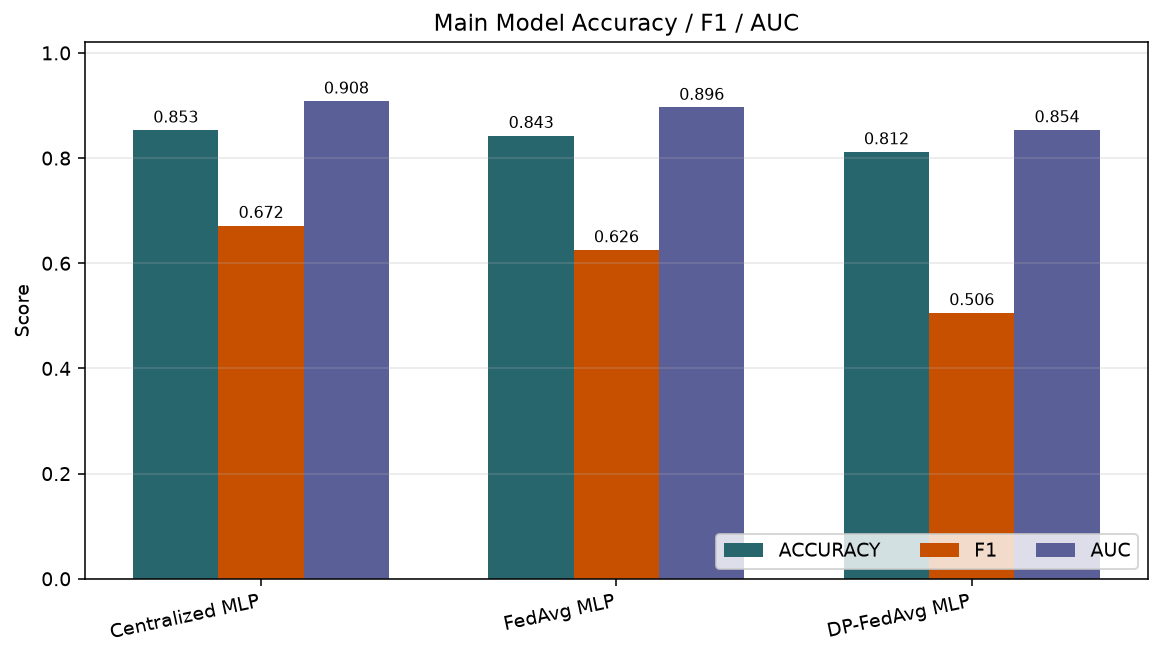

In [4]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

out = Path('data/mywork/final_outputs')
if not out.exists():
    out = Path.cwd()
# Plotting data comes from cached /train API response objects, not CSV summaries.
results = json.loads((out / 'experiment_results.json').read_text(encoding='utf-8'))
experiments = {item['name']: item for item in results['results']}

def metric_row(name):
    item = experiments[name]
    requested = item.get('requested_config') or {}
    dp = item.get('dp') or {}
    return {
        'name': name,
        **(item.get('metrics') or {}),
        'noise_multiplier': dp.get('noise_multiplier', requested.get('noise_multiplier')),
        'dirichlet_alpha': requested.get('dirichlet_alpha'),
    }

main_names = ['centralized_mlp', 'fedavg_mlp', 'dp_fedavg_mlp']
label_map = {
    'centralized_mlp': 'Centralized MLP',
    'fedavg_mlp': 'FedAvg MLP',
    'dp_fedavg_mlp': 'DP-FedAvg MLP',
}
metrics = ['accuracy', 'f1', 'auc']
plot_rows = [metric_row(name) for name in main_names]
x = np.arange(len(main_names))
width = 0.24
fig, ax = plt.subplots(figsize=(8.4, 4.8), dpi=140)
colors = ['#28666e', '#c75000', '#5b5f97']
for offset, metric, color in zip([-width, 0, width], metrics, colors):
    values = [row[metric] for row in plot_rows]
    bars = ax.bar(x + offset, values, width, label=metric.upper(), color=color)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels([label_map[name] for name in main_names], rotation=12, ha='right')
ax.set_ylim(0, 1.02)
ax.set_ylabel('Score')
ax.set_title('Main Model Accuracy / F1 / AUC')
ax.grid(axis='y', alpha=0.28)
ax.legend(ncols=3, loc='lower right')
fig.tight_layout()
plt.show()

### 训练 Accuracy 曲线

三类主要训练流程的 Accuracy 随 epoch/round 的变化。

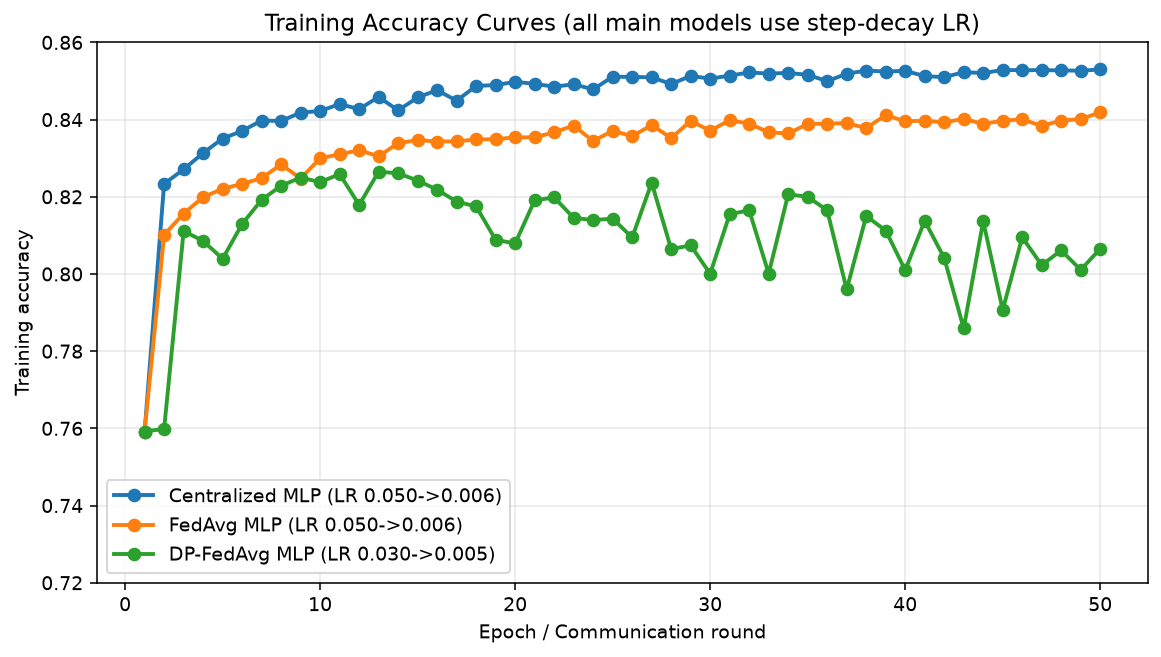

In [5]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

out = Path('data/mywork/final_outputs')
if not out.exists():
    out = Path.cwd()
# Plotting data comes from cached /train API response objects, not CSV summaries.
results = json.loads((out / 'experiment_results.json').read_text(encoding='utf-8'))
experiments = {item['name']: item for item in results['results']}

def metric_row(name):
    item = experiments[name]
    requested = item.get('requested_config') or {}
    dp = item.get('dp') or {}
    return {
        'name': name,
        **(item.get('metrics') or {}),
        'noise_multiplier': dp.get('noise_multiplier', requested.get('noise_multiplier')),
        'dirichlet_alpha': requested.get('dirichlet_alpha'),
    }

main_names = ['centralized_mlp', 'fedavg_mlp', 'dp_fedavg_mlp']
label_map = {
    'centralized_mlp': 'Centralized MLP',
    'fedavg_mlp': 'FedAvg MLP',
    'dp_fedavg_mlp': 'DP-FedAvg MLP',
}
fig, ax = plt.subplots(figsize=(8.4, 4.8), dpi=140)
for name in main_names:
    values = experiments[name]['history']['accuracy']
    lr_values = experiments[name]['history'].get('lr', [])
    lr_note = ''
    if lr_values:
        lr_note = f" (LR {lr_values[0]:.3f}->{lr_values[-1]:.3f})"
    ax.plot(range(1, len(values) + 1), values, marker='o', linewidth=2, label=label_map[name] + lr_note)
ax.set_xlabel('Epoch / Communication round')
ax.set_ylabel('Training accuracy')
ax.set_title('Training Accuracy Curves (all main models use step-decay LR)')
ax.set_ylim(0.72, 0.86)
ax.grid(alpha=0.28)
ax.legend()
fig.tight_layout()
plt.show()

### 训练 Loss 曲线

三类主要训练流程的 Loss 随 epoch/round 的变化。

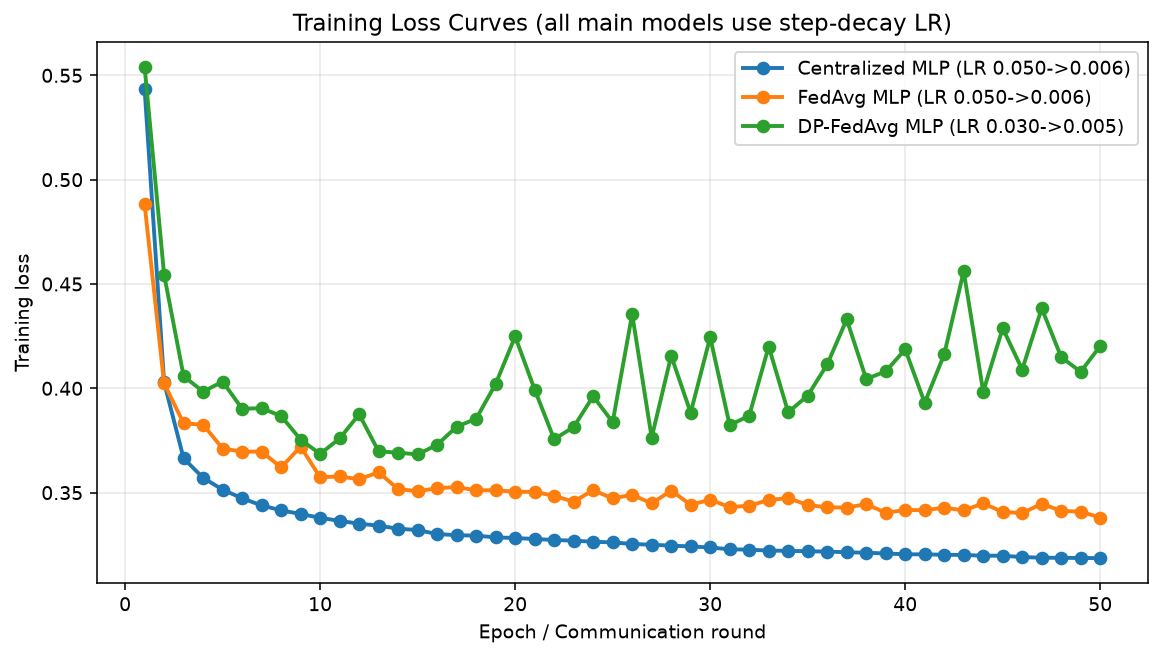

In [6]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

out = Path('data/mywork/final_outputs')
if not out.exists():
    out = Path.cwd()
# Plotting data comes from cached /train API response objects, not CSV summaries.
results = json.loads((out / 'experiment_results.json').read_text(encoding='utf-8'))
experiments = {item['name']: item for item in results['results']}

def metric_row(name):
    item = experiments[name]
    requested = item.get('requested_config') or {}
    dp = item.get('dp') or {}
    return {
        'name': name,
        **(item.get('metrics') or {}),
        'noise_multiplier': dp.get('noise_multiplier', requested.get('noise_multiplier')),
        'dirichlet_alpha': requested.get('dirichlet_alpha'),
    }

main_names = ['centralized_mlp', 'fedavg_mlp', 'dp_fedavg_mlp']
label_map = {
    'centralized_mlp': 'Centralized MLP',
    'fedavg_mlp': 'FedAvg MLP',
    'dp_fedavg_mlp': 'DP-FedAvg MLP',
}
fig, ax = plt.subplots(figsize=(8.4, 4.8), dpi=140)
for name in main_names:
    values = experiments[name]['history']['loss']
    lr_values = experiments[name]['history'].get('lr', [])
    lr_note = ''
    if lr_values:
        lr_note = f" (LR {lr_values[0]:.3f}->{lr_values[-1]:.3f})"
    ax.plot(range(1, len(values) + 1), values, marker='o', linewidth=2, label=label_map[name] + lr_note)
ax.set_xlabel('Epoch / Communication round')
ax.set_ylabel('Training loss')
ax.set_title('Training Loss Curves (all main models use step-decay LR)')
ax.grid(alpha=0.28)
ax.legend()
fig.tight_layout()
plt.show()

### 三模型混淆矩阵

集中式 MLP、FedAvg MLP 与 DP-FedAvg MLP 的混淆矩阵。

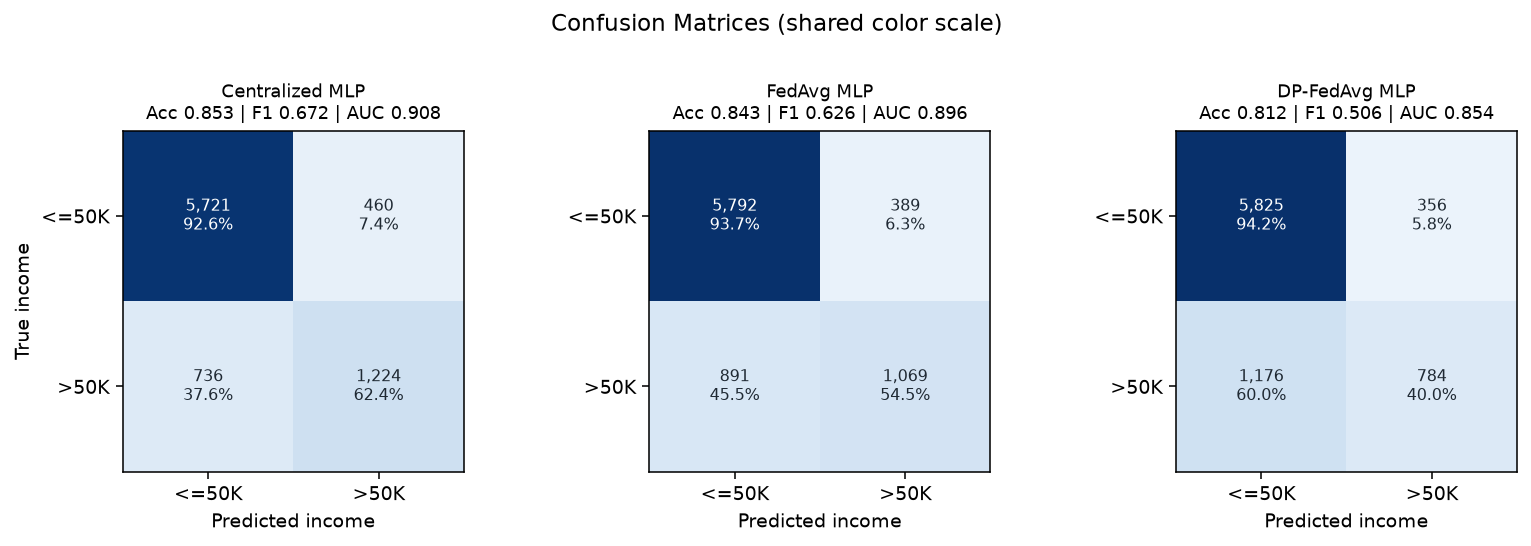

In [7]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

out = Path('data/mywork/final_outputs')
if not out.exists():
    out = Path.cwd()
# Plotting data comes from cached /train API response objects, not CSV summaries.
results = json.loads((out / 'experiment_results.json').read_text(encoding='utf-8'))
experiments = {item['name']: item for item in results['results']}

def metric_row(name):
    item = experiments[name]
    requested = item.get('requested_config') or {}
    dp = item.get('dp') or {}
    return {
        'name': name,
        **(item.get('metrics') or {}),
        'noise_multiplier': dp.get('noise_multiplier', requested.get('noise_multiplier')),
        'dirichlet_alpha': requested.get('dirichlet_alpha'),
    }

main_names = ['centralized_mlp', 'fedavg_mlp', 'dp_fedavg_mlp']
label_map = {
    'centralized_mlp': 'Centralized MLP',
    'fedavg_mlp': 'FedAvg MLP',
    'dp_fedavg_mlp': 'DP-FedAvg MLP',
}
class_labels = ['<=50K', '>50K']
matrices = {
    name: np.array(experiments[name]['metrics']['confusion_matrix'])
    for name in main_names
}
vmax = max(int(matrix.max()) for matrix in matrices.values())
fig, axes = plt.subplots(1, 3, figsize=(11.2, 4.2), dpi=140)
for idx, (ax, name) in enumerate(zip(axes, main_names)):
    matrix = matrices[name]
    metrics = experiments[name]['metrics']
    ax.imshow(matrix, cmap='Blues', vmin=0, vmax=vmax)
    ax.set_title(
        f"{label_map[name]}\n"
        f"Acc {metrics['accuracy']:.3f} | F1 {metrics['f1']:.3f} | AUC {metrics['auc']:.3f}",
        fontsize=9,
        fontweight='normal',
    )
    ax.set_xlabel('Predicted income')
    if idx == 0:
        ax.set_ylabel('True income')
    ax.set_xticks([0, 1], labels=class_labels)
    ax.set_yticks([0, 1], labels=class_labels)
    row_totals = matrix.sum(axis=1, keepdims=True)
    row_percentages = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(matrix, dtype=float),
        where=row_totals != 0,
    ) * 100
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            color = 'white' if matrix[i, j] > vmax * 0.50 else '#1f2933'
            ax.text(
                j,
                i,
                f'{matrix[i, j]:,}\n{row_percentages[i, j]:.1f}%',
                ha='center',
                va='center',
                color=color,
                fontsize=8,
            )
fig.suptitle('Confusion Matrices (shared color scale)', y=0.96, fontsize=12)
fig.subplots_adjust(left=0.07, right=0.985, top=0.76, bottom=0.18, wspace=0.38)
plt.show()

### DP 噪声敏感性

不同 noise_multiplier 下 DP-FedAvg 的指标变化，反映隐私扰动与效用之间的经验权衡。

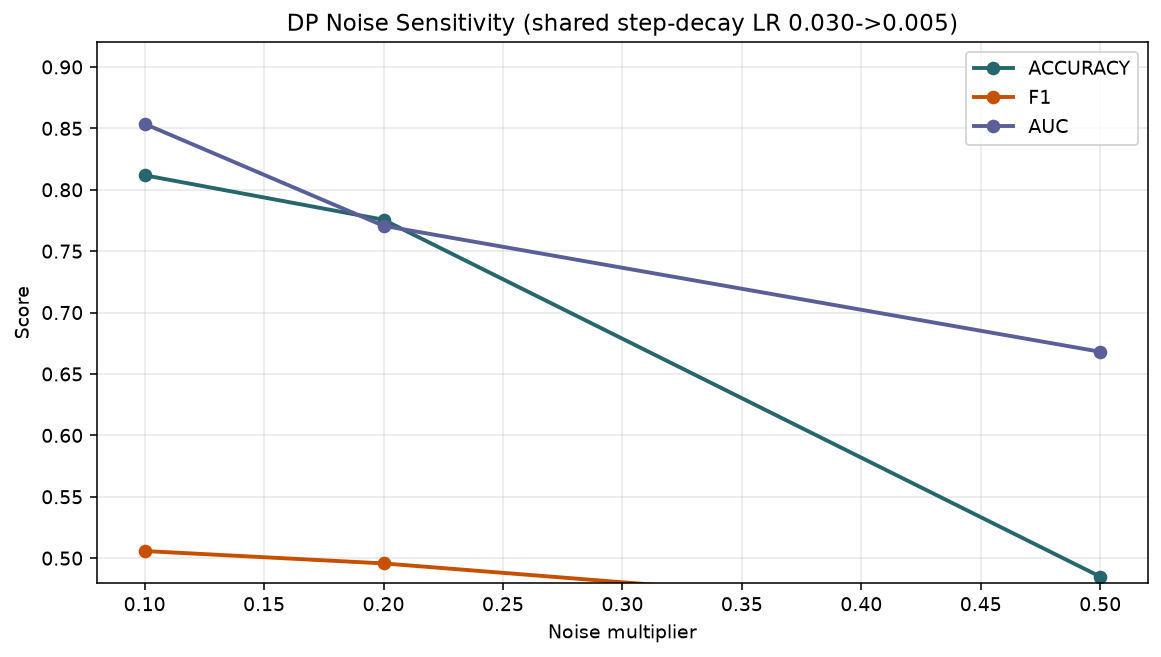

In [8]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

out = Path('data/mywork/final_outputs')
if not out.exists():
    out = Path.cwd()
# Plotting data comes from cached /train API response objects, not CSV summaries.
results = json.loads((out / 'experiment_results.json').read_text(encoding='utf-8'))
experiments = {item['name']: item for item in results['results']}

def metric_row(name):
    item = experiments[name]
    requested = item.get('requested_config') or {}
    dp = item.get('dp') or {}
    return {
        'name': name,
        **(item.get('metrics') or {}),
        'noise_multiplier': dp.get('noise_multiplier', requested.get('noise_multiplier')),
        'dirichlet_alpha': requested.get('dirichlet_alpha'),
    }

noise_rows = [metric_row(name) for name in experiments if name.startswith('dp_noise_')]
noise_rows = sorted(noise_rows, key=lambda row: row['noise_multiplier'])
noise_values = [row['noise_multiplier'] for row in noise_rows]
lr_values = experiments['dp_noise_0.1']['history'].get('lr', [])
fig, ax = plt.subplots(figsize=(8.4, 4.8), dpi=140)
for metric, color in [('accuracy', '#28666e'), ('f1', '#c75000'), ('auc', '#5b5f97')]:
    ax.plot(noise_values, [row[metric] for row in noise_rows], marker='o', linewidth=2, label=metric.upper(), color=color)
ax.set_xlabel('Noise multiplier')
ax.set_ylabel('Score')
ax.set_title(f'DP Noise Sensitivity (shared step-decay LR {lr_values[0]:.3f}->{lr_values[-1]:.3f})' if lr_values else 'DP Noise Sensitivity')
ax.set_ylim(0.48, 0.92)
ax.grid(alpha=0.28)
ax.legend()
fig.tight_layout()
plt.show()

### alpha 敏感性

本实验使用显式客户端 CSV 固定划分，因此 alpha 主要是配置记录，不代表重新采样后的 Dirichlet Non-IID 强度。

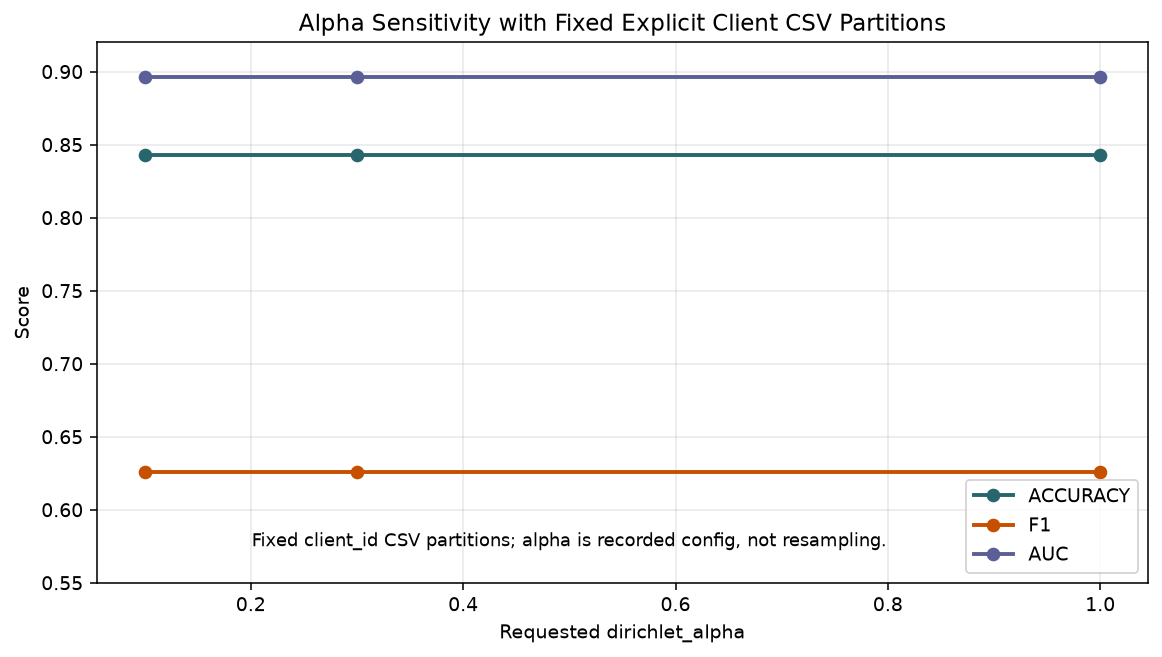

In [9]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

out = Path('data/mywork/final_outputs')
if not out.exists():
    out = Path.cwd()
# Plotting data comes from cached /train API response objects, not CSV summaries.
results = json.loads((out / 'experiment_results.json').read_text(encoding='utf-8'))
experiments = {item['name']: item for item in results['results']}

def metric_row(name):
    item = experiments[name]
    requested = item.get('requested_config') or {}
    dp = item.get('dp') or {}
    return {
        'name': name,
        **(item.get('metrics') or {}),
        'noise_multiplier': dp.get('noise_multiplier', requested.get('noise_multiplier')),
        'dirichlet_alpha': requested.get('dirichlet_alpha'),
    }

alpha_rows = [metric_row(name) for name in experiments if name.startswith('alpha_')]
alpha_rows = sorted(alpha_rows, key=lambda row: row['dirichlet_alpha'])
alpha_values = [row['dirichlet_alpha'] for row in alpha_rows]
fig, ax = plt.subplots(figsize=(8.4, 4.8), dpi=140)
for metric, color in [('accuracy', '#28666e'), ('f1', '#c75000'), ('auc', '#5b5f97')]:
    ax.plot(alpha_values, [row[metric] for row in alpha_rows], marker='o', linewidth=2, label=metric.upper(), color=color)
ax.set_xlabel('Requested dirichlet_alpha')
ax.set_ylabel('Score')
ax.set_title('Alpha Sensitivity with Fixed Explicit Client CSV Partitions')
ax.set_ylim(0.55, 0.92)
ax.grid(alpha=0.28)
ax.legend()
ax.text(0.5, 0.575, 'Fixed client_id CSV partitions; alpha is recorded config, not resampling.', ha='center', fontsize=9)
fig.tight_layout()
plt.show()

## 结论

集中式模型是合并数据参照；FedAvg 显示固定 Non-IID 客户端划分下的协作训练效果；DP-FedAvg 展示 L2 裁剪和高斯噪声机制带来的隐私-效用权衡。由于没有集成 Opacus 或严格 privacy accountant，本实验中的 epsilon/delta 只作为记录和配置的实验参数。